In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

df = sns.load_dataset('titanic')

print(" Dataset structure exploration")
print(f"Number of rows and columns: {df.shape}")
print("\nColumn names:\n",df.columns.tolist())
print("\nData types:\n",df.dtypes)
print("\nBasic stastical information:\n",df.describe(include="all"))
print("\nPresence of missing/null values (counts):\n",df.isnull().sum())

 Dataset structure exploration
Number of rows and columns: (891, 15)

Column names:
 ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Data types:
 survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Basic stastical information:
           survived      pclass   sex         age       sibsp       parch  \
count   891.000000  891.000000   891  714.000000  891.000000  891.000000   
unique         NaN         NaN     2         NaN         NaN         NaN   
top            NaN         NaN  male         NaN         NaN         NaN   
freq           NaN         NaN   577         N

/tmp/ipykernel_1412/2448219423.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='alive', y='age', palette='Pastel1', ax=axes[1, 1])


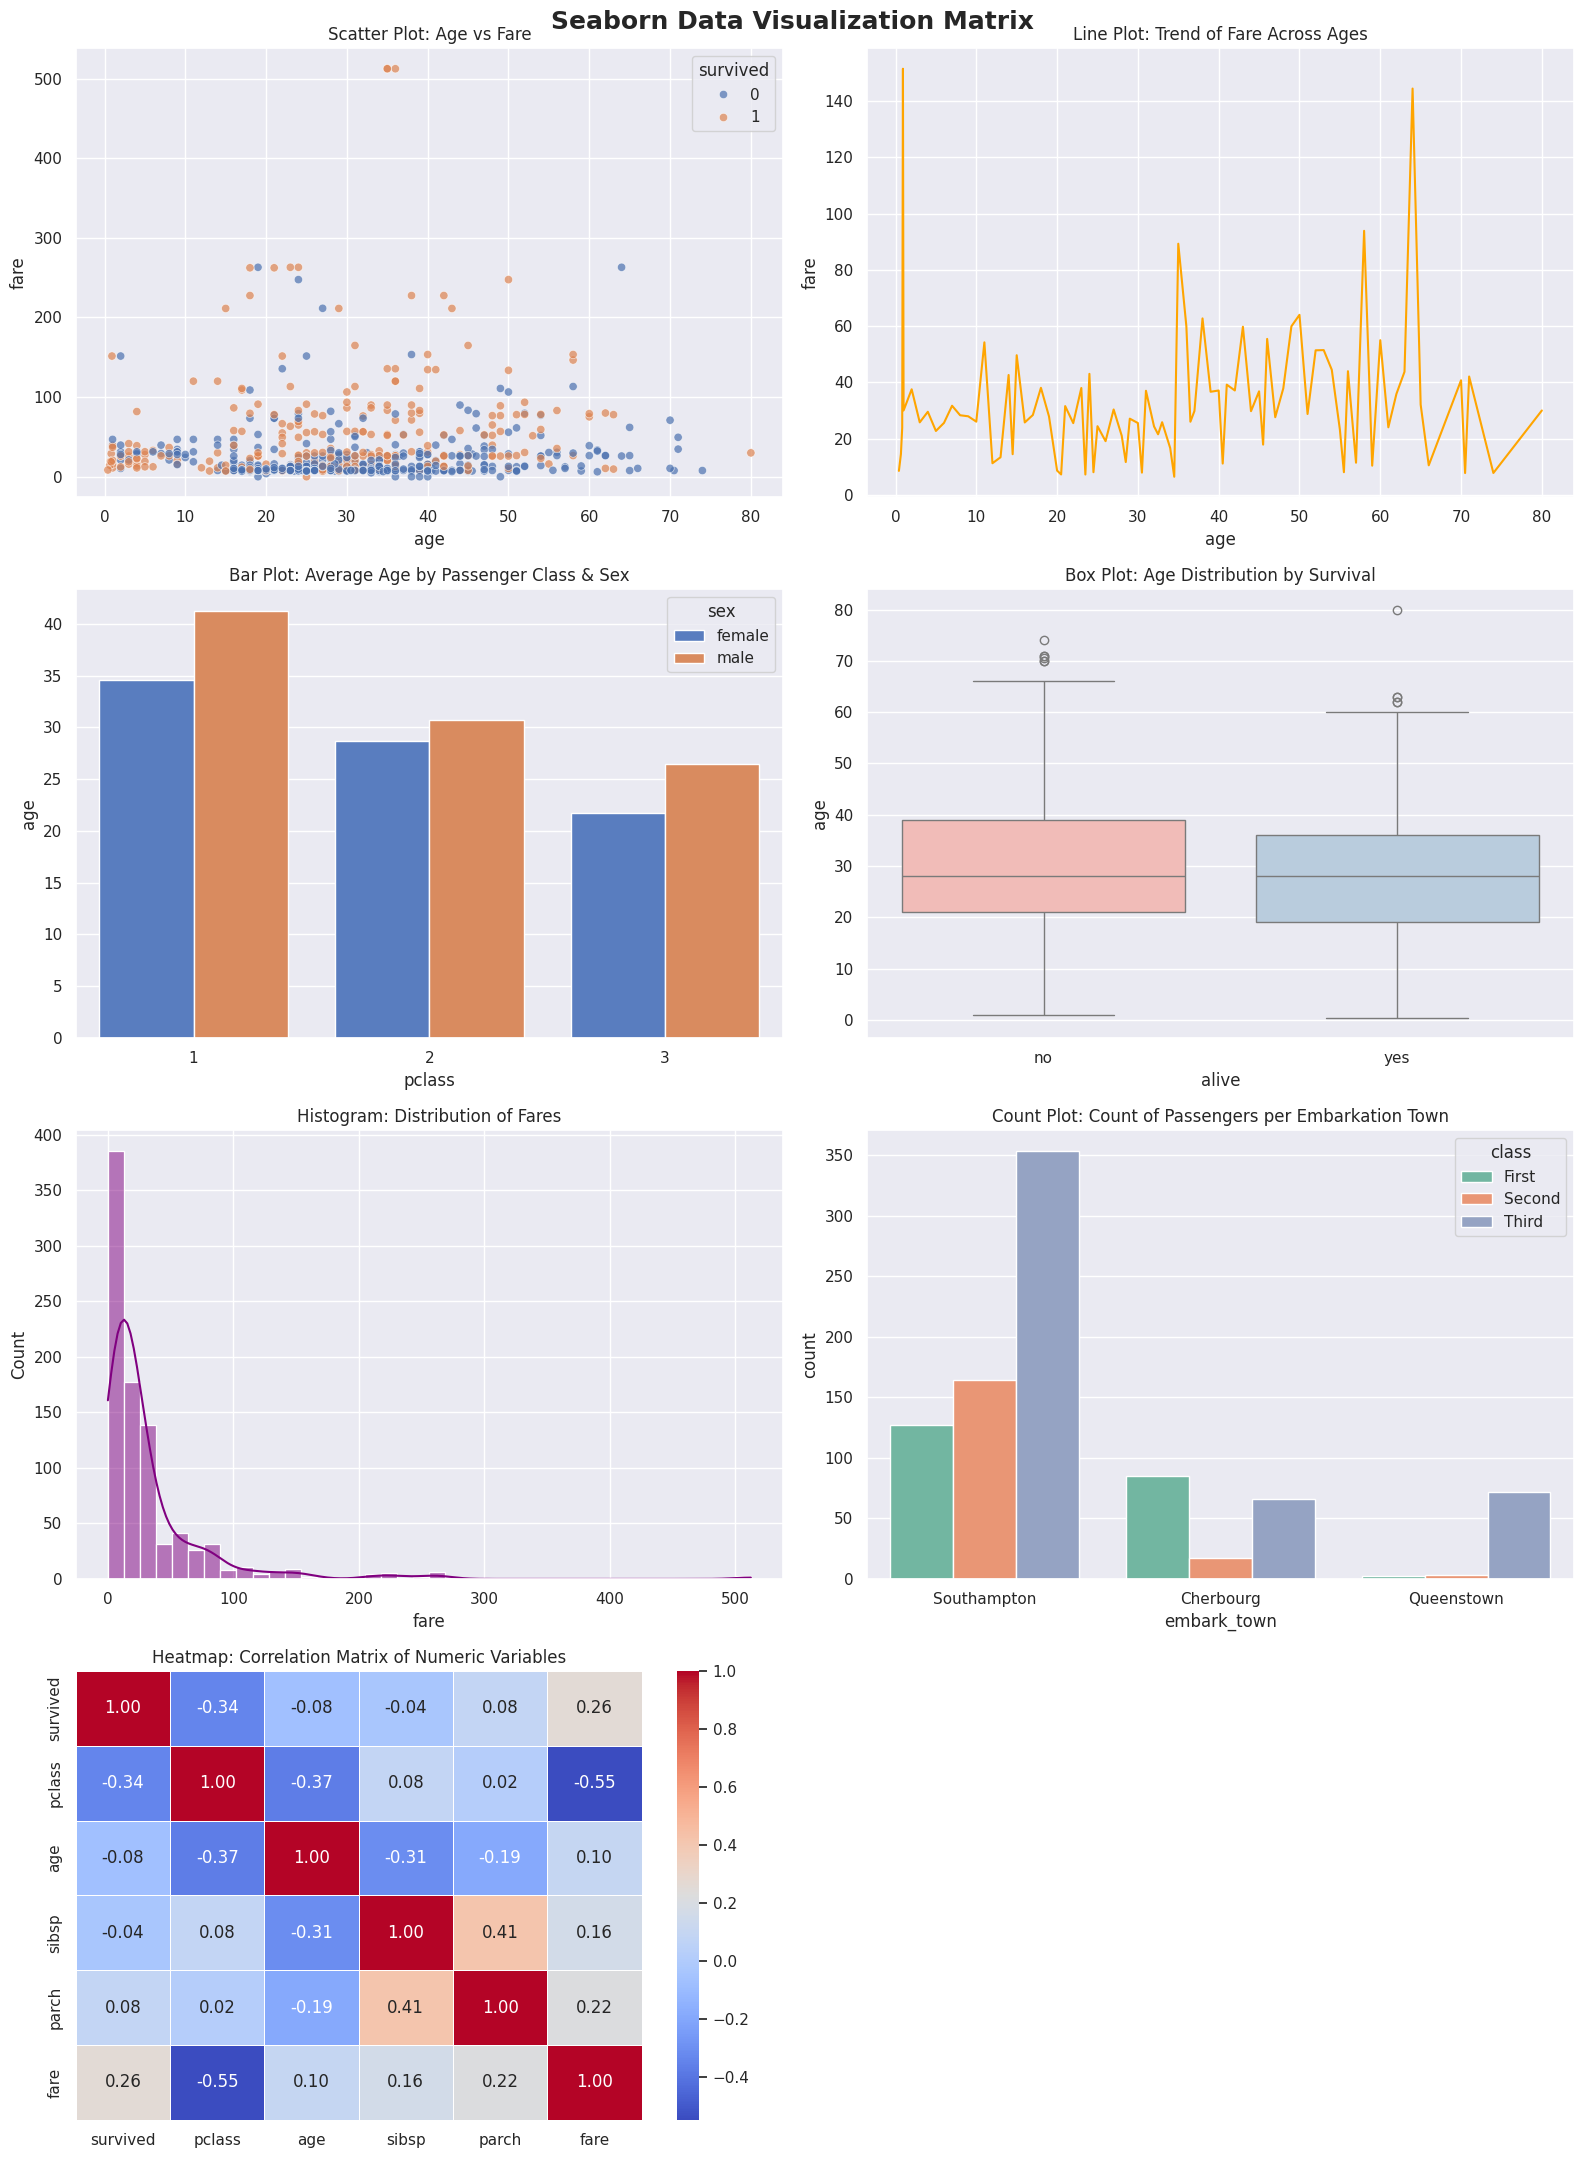

In [3]:
#Data visualization
fig, axes = plt.subplots(4, 2, figsize=(16,22))
fig.suptitle("Seaborn Data Visualization Matrix", fontsize=18, fontweight='bold', y=0.98)

sns.scatterplot(data=df, x='age', y='fare', hue='survived', alpha=0.7, ax=axes[0, 0])
axes[0, 0].set_title('Scatter Plot: Age vs Fare')

sns.lineplot(data=df.sort_values('age'), x='age', y='fare', errorbar=None, color='orange', ax=axes[0, 1])
axes[0, 1].set_title('Line Plot: Trend of Fare Across Ages')


sns.barplot(data=df, x='pclass', y='age', hue='sex', errorbar=None, palette='muted', ax=axes[1, 0])
axes[1, 0].set_title('Bar Plot: Average Age by Passenger Class & Sex')


sns.boxplot(data=df, x='alive', y='age', palette='Pastel1', ax=axes[1, 1])
axes[1, 1].set_title('Box Plot: Age Distribution by Survival')


sns.histplot(data=df, x='fare', bins=40, kde=True, color='purple', ax=axes[2, 0])
axes[2, 0].set_title('Histogram: Distribution of Fares')


sns.countplot(data=df, x='embark_town', hue='class', palette='Set2', ax=axes[2, 1])
axes[2, 1].set_title('Count Plot: Count of Passengers per Embarkation Town')


numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[3, 0])
axes[3, 0].set_title('Heatmap: Correlation Matrix of Numeric Variables')

fig.delaxes(axes[3, 1])

plt.tight_layout()
plt.show()

In [4]:
#Identify and handle null/missing values

print("\n TACKLING NULL/MISSING VALUES")
print("Null value before data cleaning:",df.isnull().sum())

df['age']= df.groupby(['pclass','sex'])['age'].transform(lambda x: x.fillna(x.median))

df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

df.drop(columns=['deck'], inplace=True)

print("\n Null count after data cleaning:",df.isnull().sum())


 TACKLING NULL/MISSING VALUES
Null value before data cleaning: survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

 Null count after data cleaning: survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64
